In [1]:
import pandas as pd
df = pd.read_csv("Cost_of_Living_Index.csv")
print(df.head())
print(df.info())
print(df.describe())

   Rank      Country  Cost of Living Index  Rent Index  \
0     1  Afghanistan                 20.37        2.72   
1     2      Albania                 35.50        8.47   
2     3      Algeria                 26.87        4.59   
3     4    Argentina                 34.69        7.71   
4     5      Armenia                 33.89       11.61   

   Cost of Living Plus Rent Index  Groceries Index  Restaurant Price Index  \
0                           12.09            14.92                   12.41   
1                           22.83            29.32                   25.82   
2                           16.43            28.82                   14.48   
3                           22.04            28.17                   33.32   
4                           23.45            27.59                   30.55   

   Local Purchasing Power Index  
0                         23.04  
1                         30.19  
2                         24.63  
3                         30.72  
4           

In [2]:
print(df.duplicated().sum())
df.drop("Rank", axis=1, inplace=True)
print(df.dtypes)


0
Country                            object
Cost of Living Index              float64
Rent Index                        float64
Cost of Living Plus Rent Index    float64
Groceries Index                   float64
Restaurant Price Index            float64
Local Purchasing Power Index      float64
dtype: object


In [3]:
df["Affordability"] = df["Local Purchasing Power Index"] >= df["Cost of Living Plus Rent Index"]
df["Affordability"] = df["Affordability"].map({True: "Affordable", False: "Not Affordable"})
print(df[["Country", "Cost of Living Plus Rent Index", "Local Purchasing Power Index", "Affordability"]].head())

       Country  Cost of Living Plus Rent Index  Local Purchasing Power Index  \
0  Afghanistan                           12.09                         23.04   
1      Albania                           22.83                         30.19   
2      Algeria                           16.43                         24.63   
3    Argentina                           22.04                         30.72   
4      Armenia                           23.45                         28.86   

  Affordability  
0    Affordable  
1    Affordable  
2    Affordable  
3    Affordable  
4    Affordable  


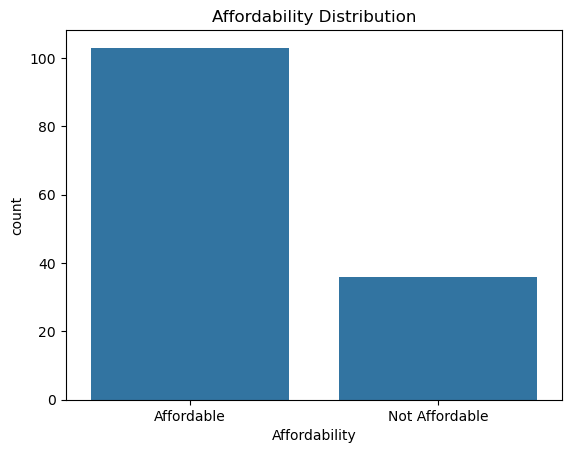

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Affordability")
plt.title("Affordability Distribution")
plt.show()

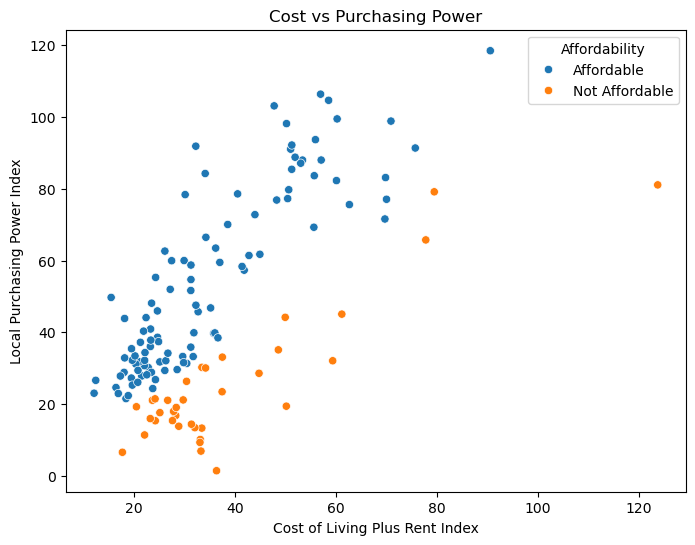

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Cost of Living Plus Rent Index",
    y="Local Purchasing Power Index",
    hue="Affordability"
)

plt.title("Cost vs Purchasing Power")
plt.show()

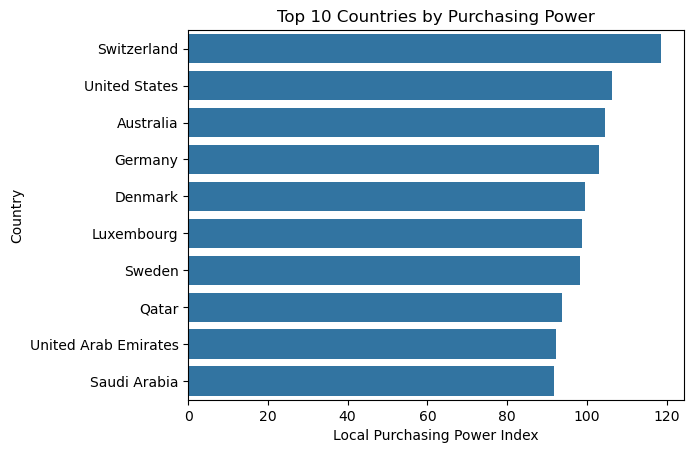

In [6]:
top10 = df.sort_values(by="Local Purchasing Power Index", ascending=False).head(10)

sns.barplot(data=top10, x="Local Purchasing Power Index", y="Country")
plt.title("Top 10 Countries by Purchasing Power")
plt.show()

In [8]:
df["Income_to_Cost_Ratio"] = df["Local Purchasing Power Index"] / df["Cost of Living Plus Rent Index"]
print(df[["Country", "Income_to_Cost_Ratio"]])

         Country  Income_to_Cost_Ratio
0    Afghanistan              1.905707
1        Albania              1.322383
2        Algeria              1.499087
3      Argentina              1.393829
4        Armenia              1.230704
..           ...                   ...
134    Venezuela              0.557727
135      Vietnam              1.125239
136        Yemen              0.459210
137       Zambia              1.841553
138     Zimbabwe              0.672189

[139 rows x 2 columns]


In [9]:
df_sorted = df.sort_values(by="Income_to_Cost_Ratio", ascending=False)
print(df_sorted[["Country", "Income_to_Cost_Ratio"]].head(10))

                         Country  Income_to_Cost_Ratio
52                         India              3.213963
105                 Saudi Arabia              2.848062
113                 South Africa              2.599867
91                          Oman              2.469657
66   Kosovo (Disputed Territory)              2.417861
18                      Botswana              2.397779
74                      Malaysia              2.276657
98                        Poland              2.183176
43                       Germany              2.157388
92                      Pakistan              2.144122


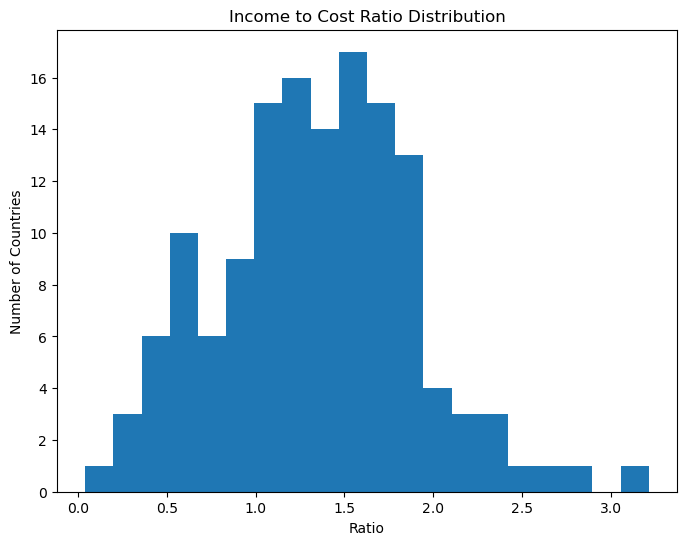

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(df["Income_to_Cost_Ratio"], bins=20)
plt.title("Income to Cost Ratio Distribution")
plt.xlabel("Ratio")
plt.ylabel("Number of Countries")
plt.show()

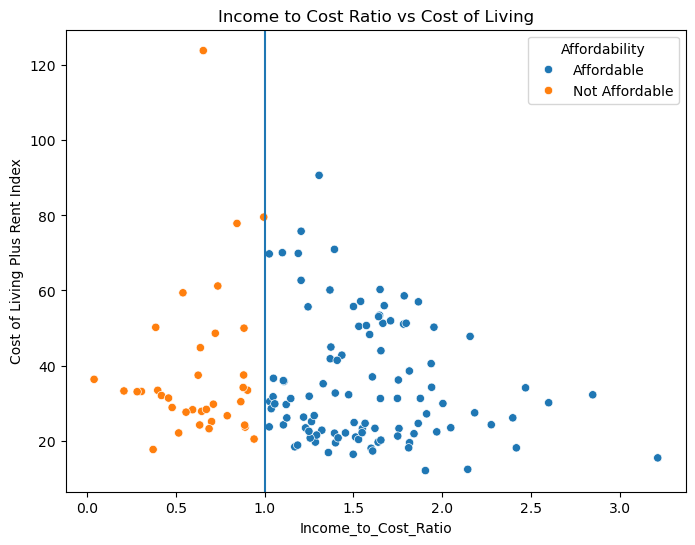

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Income_to_Cost_Ratio",
    y="Cost of Living Plus Rent Index",
    hue="Affordability"
)

plt.axvline(x=1)  
plt.title("Income to Cost Ratio vs Cost of Living")
plt.show()

In [12]:
def classify_ratio(x):
    if x < 0.8:
        return "Poor"
    elif x < 1:
        return "Average"
    else:
        return "Good"

df["Affordability_Level"] = df["Income_to_Cost_Ratio"].apply(classify_ratio)

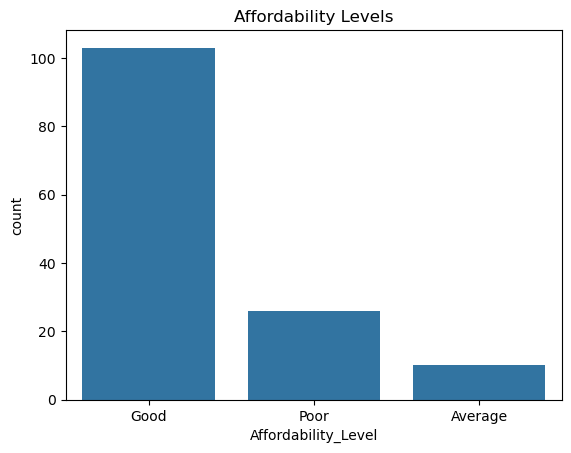

In [ ]:
sns.countplot(data=df, x="Affordability_Level")
plt.title("Affordability Levels")
plt.show()

In [14]:
print(df.sort_values(by="Income_to_Cost_Ratio", ascending=False)[["Country", "Income_to_Cost_Ratio"]].head())

print(df.sort_values(by="Income_to_Cost_Ratio")[["Country", "Income_to_Cost_Ratio"]].head())

                         Country  Income_to_Cost_Ratio
52                         India              3.213963
105                 Saudi Arabia              2.848062
113                 South Africa              2.599867
91                          Oman              2.469657
66   Kosovo (Disputed Territory)              2.417861
         Country  Income_to_Cost_Ratio
29          Cuba              0.039879
59   Ivory Coast              0.207995
88       Nigeria              0.282431
38      Ethiopia              0.306276
120        Syria              0.372316


In [2]:
import pandas as pd
df = pd.read_csv("Cost_of_Living_Processed.csv")
df.head()

,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Affordability,Income_to_Cost_Ratio,Affordability_Level
0,Afghanistan,20.37,2.72,12.09,14.92,12.41,23.04,Affordable,1.905707,Good
1,Albania,35.50,8.47,22.83,29.32,25.82,30.19,Affordable,1.322383,Good
2,Algeria,26.87,4.59,16.43,28.82,14.48,24.63,Affordable,1.499087,Good
3,Argentina,34.69,7.71,22.04,28.17,33.32,30.72,Affordable,1.393829,Good
4,Armenia,33.89,11.61,23.45,27.59,30.55,28.86,Affordable,1.230704,Good


In [3]:
y = df['Affordability_Level']
X = df.drop(['Country', 'Affordability_Level', 'Affordability'], axis=1)

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9642857142857143
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00        21
           2       0.83      1.00      0.91         5

    accuracy                           0.96        28
   macro avg       0.94      0.83      0.86        28
weighted avg       0.97      0.96      0.96        28



In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(dt_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Cross Validation Scores: [1.         1.         0.96428571 1.         1.        ]
Mean CV Accuracy: 0.9928571428571429
Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00         5

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Cross Validation Scores: [0.92857143 1.         0.96428571 1.         1.        ]
Mean CV Accuracy: 0.9785714285714284
Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00         5

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



In [16]:
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

cols_to_exclude = ['Country', 'Affordability', 'Affordability_Level']
X = df.drop(columns=[c for c in cols_to_exclude if c in df.columns])

X = X.select_dtypes(include=[np.number])
y = df['Affordability_Level']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

models = {
    "SVM": SVC(kernel='linear', C=1.0),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50 + "\n")

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)

    print(f"MODEL: {name}")
    print(f"Test Accuracy: {acc:.2%}")
    print(f"Cross-Validation Mean: {cv_scores.mean():.2%}")
    print("-" * 30)
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("=" * 50 + "\n")


MODEL EVALUATION RESULTS

MODEL: SVM
Test Accuracy: 89.29%
Cross-Validation Mean: 92.81%
------------------------------
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00         2
        Good       0.95      0.95      0.95        21
        Poor       0.83      1.00      0.91         5

    accuracy                           0.89        28
   macro avg       0.60      0.65      0.62        28
weighted avg       0.86      0.89      0.88        28


MODEL: KNN
Test Accuracy: 78.57%
Cross-Validation Mean: 91.03%
------------------------------
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00         2
        Good       0.83      0.95      0.89        21
        Poor       1.00      0.40      0.57         5

    accuracy                           0.79        28
   macro avg       0.61      0.45      0.49        28
weighted avg       0.80      0.79      0.77        28


MODEL: Gradient Boost